In [23]:
import tensorflow as tf
from keras.datasets import mnist
from tensorflow.keras import datasets
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from keras.layers import Dense, Flatten
from keras.models import Sequential
from tensorflow import keras
import matplotlib.pyplot as plt

import cv2

In [2]:
print(tf.__version__)

2.20.0


In [3]:
# load dataset
(x_train, y_train) , (x_test, y_test) = datasets.mnist.load_data()

In [4]:
x_train.shape, y_train.shape

((60000, 28, 28), (60000,))

In [5]:
x_train.shape[0]

60000

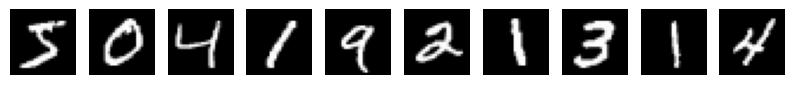

In [7]:
# Display the first 10 images in the training set
plt.figure(figsize=(10, 1))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')  # reshape back to 28x28
    plt.axis('off')  # hide axes
plt.show()


In [8]:
# CNN expects 3D input: (height, width, channels)
# reshape data
# CNN expects 4D input: (batch_size, height, width, channels) channels = 1- grayscale image, 

x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)


In [9]:
# Normalization
x_train = x_train / 255
x_test = x_test / 255

In [10]:
# One Hot encoding the labels
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

In [11]:
y_test.shape

(10000, 10)

In [12]:
y_test[10], y_test.dtype

(array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), dtype('float64'))

In [ ]:
# Build LetNet5 Model
model = Sequential([
    # Convolution + Pooling
    Conv2D(6, kernel_size=(5, 5), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D(2, 2),

    Conv2D(16, kernel_size=(5, 5), activation="relu"),
    MaxPooling2D(2, 2),

    Conv2D(120, kernel_size=(5, 5), activation="relu", padding="same"),  #  padding="same" mean output size = input size

    # Flatten + Fully Connected Layers
    Flatten(),
    Dense(120, activation="relu"),
    Dense(84, activation="relu"),
    Dense(10, activation="softmax") # # 10 classes for digits 0–9

])

 


d:\machine-learning\computer vision\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 120)      │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1920)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │       230,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 292,226 (1.11 MB)

 Trainable params: 292,226 (1.11 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Compile the model
# model.compile(optimizer="adam", loss="sparse_categorical_crossentropy",  metrics=["accuracy"])
model.compile(loss=keras.metrics.categorical_crossentropy, optimizer=keras.optimizers.Adam(), metrics=['accuracy'])

In [18]:
# train model
model.fit(x_train, y_train, epochs=50, batch_size=128, validation_data=(x_test, y_test))

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9223 - loss: 0.2542 - val_accuracy: 0.9696 - val_loss: 0.0929
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9776 - loss: 0.0711 - val_accuracy: 0.9838 - val_loss: 0.0529
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9847 - loss: 0.0483 - val_accuracy: 0.9853 - val_loss: 0.0419
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9880 - loss: 0.0374 - val_accuracy: 0.9861 - val_loss: 0.0420
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9903 - loss: 0.0311 - val_accuracy: 0.9863 - val_loss: 0.0405
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9914 - loss: 0.0264 - val_accuracy: 0.9883 - val_loss: 0.0402
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9928 - loss: 0.0222 - val_accuracy: 0.9865 - val_loss: 0.0455
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9936 - loss: 0.0193 - val_accuracy: 0.

In [19]:
score = model.evaluate(x_test, y_test, verbose=2)

print("Test loss", score[0])
print("Test accuracy", score[1])

313/313 - 1s - 2ms/step - accuracy: 0.9906 - loss: 0.0521
Test loss 0.05213703587651253
Test accuracy 0.9905999898910522


In [ ]:
# model.save("mnist_lenet5.h5")

In [30]:
import numpy as np
import matplotlib.pyplot as plt

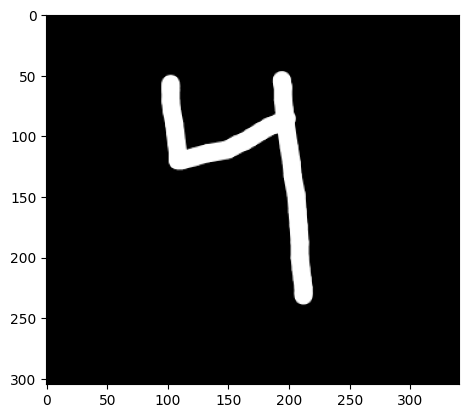

In [28]:
image = cv2.imread("../dataset/test-digit/digit01.png")
plt.imshow(image)

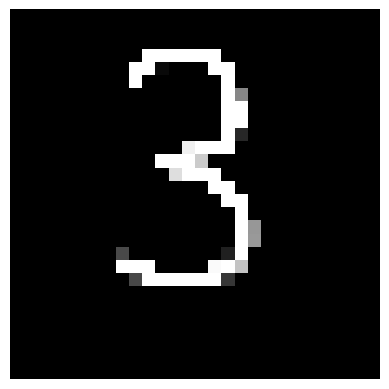

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Predicted Digit: 3


In [42]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image in grayscale
test_image = cv2.imread("../dataset/test-digit/digit02.png", cv2.IMREAD_GRAYSCALE)

# Resize to 28x28
test_image = cv2.resize(test_image, (28, 28))

# Normalize
test_image = test_image / 255.0

# Display the image
plt.imshow(test_image, cmap='gray')
plt.axis('off')
plt.show()

# Reshape to match model input (28,28,1) and add batch dimension
test_image_input = test_image.reshape(1, 28, 28, 1)

# Predict
prediction = model.predict(test_image_input)
predicted_label = np.argmax(prediction)

print("Predicted Digit:", predicted_label)
